In [1]:
# importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load the cleaned dataset from Google Drive
df=pd.read_csv('/content/drive/MyDrive/cleaned_dataset.csv')

In [5]:
# Display the first few rows of the dataset
df.head()

,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.1,3.8,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.8,3.6,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.8,3.9,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.7,3.9,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.4,4.4,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [6]:
# Selecting Dependent and Independent Variables
X = df.drop(["Time_taken_min",'Average_Speed_kmph'], axis=1)
y = df["Time_taken_min"]

In [7]:
# Split the data into training and testing parts
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
# Seperation of numerical and categorical Features
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

print("Numerical:", list(num_cols))
print("Categorical:", list(cat_cols))

Numerical: ['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating', 'Order_Items', 'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals']
Categorical: ['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Restaurant_Load', 'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority']


In [9]:
# Define nominal and ordinal feature groups for encoding
nominal_col=['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type']
ordinal_col=['Restaurant_Load','Delivery_Distance_Category','Traffic_Level', 'Delivery_Priority']

In [10]:
# Pipeline for numerical features (imputation and scaling)
num_pipeline=Pipeline([
        ('imputer',SimpleImputer(strategy='mean')),
        ('scalar',StandardScaler())
    ])

In [11]:
# Pipeline for numerical features (imputation and scaling)
nominal_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scalar',OneHotEncoder(handle_unknown='ignore'))
])

In [12]:
# Pipeline for ordinal categorical features (imputation and ordinal encoding)
ordinal_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scalar',OrdinalEncoder(
        categories=[
            ["Low", "Medium", "High"],
            ["Short", "Medium", "Long"],
            ["Low", "Moderate", "High", "Severe"],
            ["Normal", "Priority", "VIP"]
        ])
    )
])

In [13]:
# Combine numerical, nominal, and ordinal feature pipelines
preprocessor=ColumnTransformer(
    transformers=(
        ('num',num_pipeline,num_cols),
        ('nominal',nominal_pipeline,nominal_col),
        ('ordinal',ordinal_pipeline,ordinal_col)
    ),remainder='drop'
)

In [14]:
# Initialize the Linear Regression model
model=SVR()

In [15]:
# Create a ML pipeline combining preprocessor and model
pipe=Pipeline(
    [('Preprocessor',preprocessor),
    ('model',model)]
)

In [16]:
# Train the pipeline on the training data
pipe.fit(X_train,y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=(('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  Index(['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years',
       'Rider_Rating', 'Restaurant_Rating', 'Order_Items',
       'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals'],
      dtype='object')),
                                                 ('no...
                                                   'Cuisine_Type']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scalar',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High'],
                                                                                              ['Short',
                                                                                               'Medium',
                                                                                               'Long'],
                                                                                              ['Low',
                                                                                               'Moderate',
                                                                                               'High',
                                                                                               'Severe'],
                                                                                              ['Normal',
                                                                                               'Priority',
                                                                                               'VIP']]))]),
                                                  ['Restaurant_Load',
                                                   'Delivery_Distance_Category',
                                                   'Traffic_Level',
                                                   'Delivery_Priority'])))),
                ('model', SVR())])

In [17]:
# Generate predictions on the test dataset
y_pred=pipe.predict(X_test)

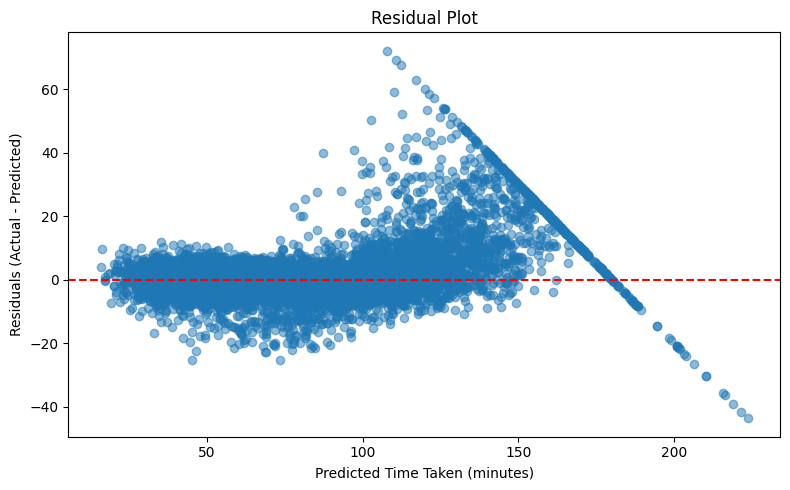

In [18]:
# Compute residuals
residuals = y_test - y_pred

# Scatter plot of residuals vs predictions
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Time Taken (minutes)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

In [19]:
# Compute evaluation metrics (MAE, MSE, RMSE, R2)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2score=r2_score(y_test,y_pred)

print(f"MAE  : {mae}")
print(f"MSE  : {mse}")
print(f"RMSE : {rmse}")
print(f"R²   : {r2score}")

MAE  : 4.784636381268291
MSE  : 67.65986324353172
RMSE : 8.225561576180176
R²   : 0.9467343029136929


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    pipe,
    param_distributions={
        "model__C": [1, 10, 100],
        "model__gamma": [0.01, 0.1],
        "model__kernel": ["rbf"]
    },
    n_iter=4,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
